In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

In [2]:
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize= 0.4)
X = lfw_people.images      # image data (pixels)
y = lfw_people.target      # labels (people)

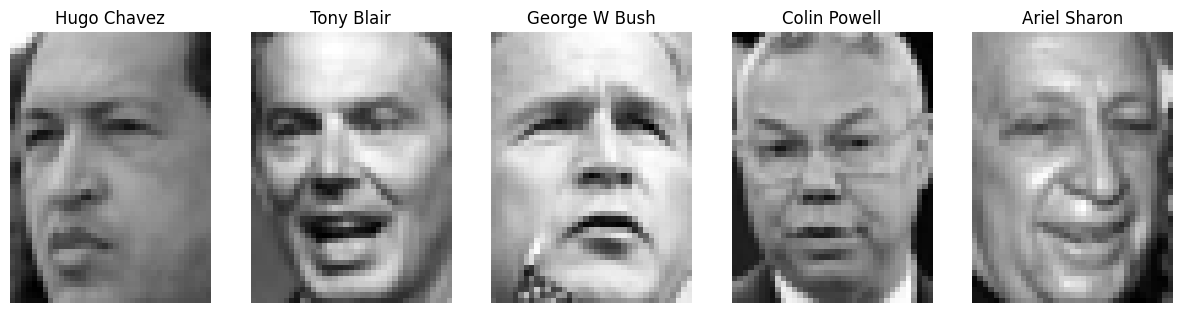

In [3]:
# Show some sample faces from the dataset
fig, axes = plt.subplots(1, 5, figsize=(15, 10))
for i, ax in enumerate(axes):
    ax.imshow(X[i], cmap='gray')
    ax.set_title(lfw_people.target_names[y[i]])
    ax.axis('off')
plt.show()

In [4]:
# Reshape and normalize the images
X = X.reshape(X.shape[0], 50, 37, 1)  # Reshape to (n_samples, height, width, channels)
X = X / 255.0  # Normalize the images to range [0, 1]

In [5]:
y = to_categorical(y)

# 3. Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
# Define a CNN model
def create_cnn_model(input_shape):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(y_train.shape[1], activation='softmax'))  # Output layer with softmax activation
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [7]:
# Create the model
model = create_cnn_model((50, 37, 1))

In [8]:
# train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10
33/33 [==============================] - 46s 19ms/step - loss: 1.7741 - accuracy: 0.3893 - val_loss: 1.6052 - val_accuracy: 0.4612
Epoch 2/10
33/33 [==============================] - 0s 5ms/step - loss: 1.7245 - accuracy: 0.3990 - val_loss: 1.6058 - val_accuracy: 0.4612
Epoch 3/10
33/33 [==============================] - 0s 5ms/step - loss: 1.7167 - accuracy: 0.3990 - val_loss: 1.5973 - val_accuracy: 0.4612
Epoch 4/10
33/33 [==============================] - 0s 5ms/step - loss: 1.7242 - accuracy: 0.3990 - val_loss: 1.5929 - val_accuracy: 0.4612
Epoch 5/10
33/33 [==============================] - 0s 5ms/step - loss: 1.7139 - accuracy: 0.3990 - val_loss: 1.6163 - val_accuracy: 0.4612
Epoch 6/10
33/33 [==============================] - 0s 5ms/step - loss: 1.7066 - accuracy: 0.3990 - val_loss: 1.6051 - val_accuracy: 0.4612
Epoch 7/10
33/33 [==============================] - 0s 5ms/step - loss: 1.7052 - accuracy: 0.3990 - val_loss: 1.6200 - val_accuracy: 0.4612
Epoch 8/10
33/33 [

In [9]:
#  Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc * 100:.2f}%")

9/9 [==============================] - 0s 11ms/step - loss: 1.6118 - accuracy: 0.4612
Test accuracy: 46.12%


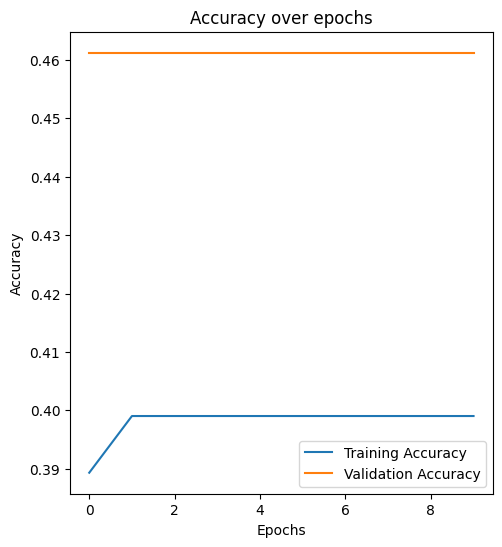

In [10]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

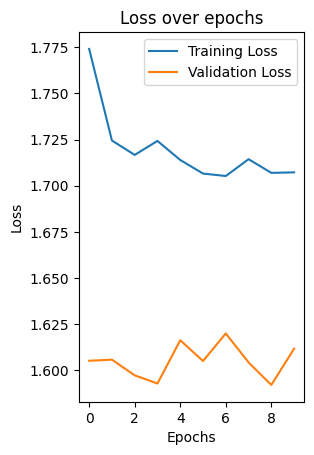

In [11]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

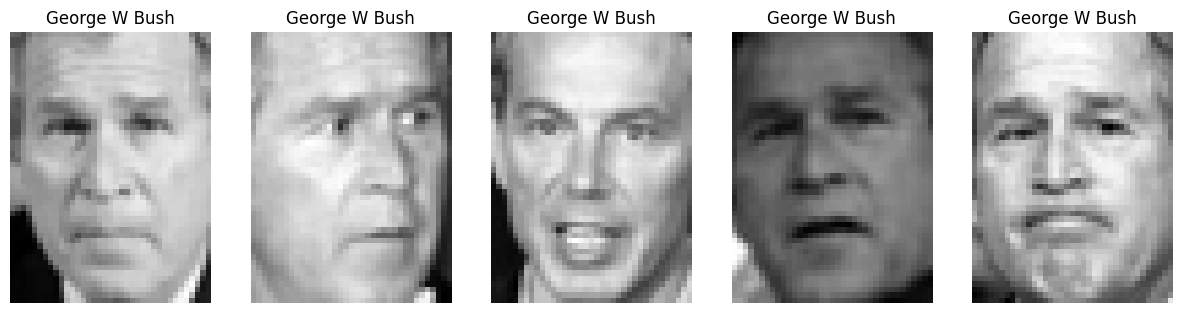

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(15, 10))
for i, ax in enumerate(axes):
    ax.imshow(X_test[i], cmap='gray')
    predicted_label = np.argmax(model.predict(np.expand_dims(X_test[i], axis=0)))
    ax.set_title(lfw_people.target_names[predicted_label])
    ax.axis('off')
plt.show()